In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path
import os
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from sklearn.linear_model import LinearRegression
from scipy.stats import t as t_dist   

from train_utils import get_info
from model import DiagnosticModel
from data import DicomDataset

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# DataFrame Metrics

In [3]:
folders = [Path("../../outputs6")]

In [4]:
all_experiments = []

for base in folders:
    for exp_name in os.listdir(base):
        exp_path = base / exp_name
        if not exp_path.is_dir():
            continue

        params_path  = exp_path / "params.json"

        for run_name in os.listdir(exp_path):
            run_path = exp_path / run_name
            if not run_path.is_dir():
                continue

            # model_path   = run_path / "best_model.pth"
            results_path = run_path / "test_results.json"

            if not results_path.exists():
                continue

            with open(params_path, "r") as f:
                params = json.load(f)

            with open(results_path, "r") as f:
                results = json.load(f)

            with open(run_path / 'info.json') as f:
                run_info = json.load(f)

            entry = {
                "exp": exp_name,
                "run": run_name,
                "auc": float(results["auc"]),
                "train_pos": run_info['train_cnt']['pos'],
                "train_neg": run_info['train_cnt']['neg'],
                "val_pos": run_info['val_cnt']['pos'],
                "val_neg": run_info['val_cnt']['neg'],
                "test_pos": run_info['test_cnt']['pos'],
                "test_neg": run_info['test_cnt']['neg'],
            }

            # Add confusion-matrix-derived metrics
            for k, v in get_info(np.array(results["val_cfvalues"])).items():
                entry[k] = v

            all_experiments.append(entry)


/data/vision/polina/users/marcusbl/bin_class/src/train_utils.py:105: RuntimeWarning: invalid value encountered in scalar divide
  info['prec'] = info['tp'] / (info['tp'] + info['fp'])


In [5]:
df = pd.DataFrame(all_experiments)

# Convert the meta columns into index
df = df.set_index(["exp", "run"]).sort_index()
pd.set_option('display.max_rows', None)
df

auc  train_pos  train_neg  val_pos  val_neg  \
exp               run                                                      
mm_hide           run0  0.896102        851       4391      326     1109   
                  run1  0.914484        811       3610      226     1238   
                  run2  0.852008        891       3407      246     1312   
                  run3  0.885178        963       3688      154      957   
                  run4  0.896708        984       4116      225      884   
                  run5  0.855080        952       4616      186      457   
mm_hide2          run0  0.863859       1033       4580      183      867   
                  run1  0.899616        911       4076      269     1014   
                  run2  0.809930        872       4002      222      941   
                  run3  0.863460        707       3606      434     1410   
                  run4  0.936134        821       3332      108     1215   
                  run5  0.872257       1108       4232      147      510   
mm_none           run0  0.900832        851       4391      326     1109   
                  run1  0.924847        811       3610      226     1238   
                  run2  0.834412        891       3407      246     1312   
                  run3  0.830435        963       3688      154      957   
                  run4  0.885556        984       4116      225      884   
                  run5  0.877340        952       4616      186      457   
mm_none2          run0  0.879345       1033       4580      183      867   
                  run1  0.888492        911       4076      269     1014   
                  run2  0.787690        872       4002      222      941   
                  run3  0.871411        707       3606      434     1410   
                  run4  0.907095        821       3332      108     1215   
                  run5  0.913515       1108       4232      147      510   
mm_none2_untrain  run0  0.813712       1033       4580      183      867   
                  run1  0.864122        911       4076      269     1014   
                  run2  0.771938        872       4002      222      941   
                  run3  0.580444        707       3606      434     1410   
                  run4  0.868001        821       3332      108     1215   
                  run5  0.887624       1108       4232      147      510   
mm_none_untrain   run0  0.824916        851       4391      326     1109   
                  run1  0.871102        811       3610      226     1238   
                  run2  0.821879        891       3407      246     1312   
                  run3  0.794979        963       3688      154      957   
                  run4  0.681574        984       4116      225      884   
                  run5  0.786868        952       4616      186      457   
mm_stack          run0  0.894891        851       4391      326     1109   
                  run1  0.921633        811       3610      226     1238   
                  run2  0.878728        891       3407      246     1312   
                  run3  0.843765        963       3688      154      957   
                  run4  0.881950        984       4116      225      884   
                  run5  0.863336        952       4616      186      457   
mm_stack2         run0  0.856769       1033       4580      183      867   
                  run1  0.916640        911       4076      269     1014   
                  run2  0.806215        872       4002      222      941   
                  run3  0.856588        707       3606      434     1410   
                  run4  0.922322        821       3332      108     1215   
                  run5  0.932484       1108       4232      147      510   
mm_stack2_untrain run0  0.827057       1033       4580      183      867   
                  run1  0.842579        911       4076      269     1014   
                  run2  0.553298        872       4002      222      941   
 

In [6]:
exp_avg = df.groupby("exp").mean().sort_values(by='auc', ascending=False)
exp_avg

,auc,train_pos,train_neg,val_pos,val_neg,test_pos,test_neg,tn,fp,fn,tp,tpr,fpr,prec,recall,f1,acc
exp,,,,,,,,,,,,,,,,,
mm_hide,0.883260,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.714354,0.090610,0.064691,0.130344,0.671629,0.112349,0.600264,0.671629,0.619972,0.844699
mm_stack2,0.881836,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.716810,0.097262,0.052243,0.133685,0.708648,0.122171,0.591706,0.708648,0.636764,0.850495
mm_stack,0.880717,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.711744,0.093221,0.055960,0.139076,0.696373,0.116356,0.608942,0.696373,0.638024,0.850819
mm_none,0.875570,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.716342,0.088622,0.055620,0.139415,0.697088,0.110148,0.616179,0.697088,0.643654,0.855758
mm_none2,0.874591,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.739522,0.074549,0.058008,0.127921,0.682525,0.093621,0.656313,0.682525,0.663633,0.867443
mm_hide2,0.874209,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.707455,0.106616,0.055845,0.130083,0.657808,0.134570,0.567911,0.657808,0.591541,0.837538
temp,0.841148,1324.166667,4151.000000,427.500000,1154.666667,403.333333,1060.333333,0.577171,0.142415,0.083063,0.197351,0.711655,0.193138,0.578779,0.711655,0.627954,0.774522
mm_stack_untrain,0.837083,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.631423,0.173542,0.056946,0.138090,0.717207,0.215150,0.453286,0.717207,0.541183,0.769512
mm_none2_untrain,0.797640,908.666667,3971.333333,227.166667,992.833333,227.166667,992.833333,0.660654,0.153418,0.071845,0.114084,0.608810,0.191408,0.422218,0.608810,0.532278,0.774737


## Explore Effect of Dataset Distributions on AUC

We attempt to fit a multi-variate regression of AUC vs. {train_pos_ratio, val_pos_ratio, test_pos_ratio} to see if the pos_ratio of the datasets affects the final AUC

In [11]:
def regression_for_experiment(exp: str, gdf: pd.DataFrame):
    """
    gdf = all runs belonging to ONE experiment (exp)
    """
    # --- Create predictors correctly ---
    # x_train = np.array(gdf['train_pos'] + gdf['train_neg'], dtype=np.float32)
    # x_val   = np.array(gdf['val_pos']   + gdf['val_neg'], dtype=np.float32)
    # x_test  = np.array(gdf['test_pos']  + gdf['test_neg'], dtype=np.float32)

    x_train = np.array(gdf['train_pos'] / (gdf['train_pos'] + gdf['train_neg']), dtype=np.float32)
    x_val   = np.array(gdf['val_pos']   / (gdf['val_pos']   + gdf['val_neg']), dtype=np.float32)
    x_test  = np.array(gdf['test_pos']  / (gdf['test_pos']  + gdf['test_neg']), dtype=np.float32)

    X = np.column_stack([x_train, x_val, x_test])
    y = np.array(gdf['auc'], dtype=float)
    
    # Add intercept manually
    X_design = np.column_stack([np.ones(len(X)), X])

    n, p = X_design.shape
    df = n - p

    if df <= 0:
        return None  # underdetermined

    # --- Fit OLS in sklearn ---
    reg = LinearRegression(fit_intercept=False).fit(X_design, y)
    beta = reg.coef_
    y_pred = reg.predict(X_design)

    # --- Stats ---
    resid = y - y_pred
    sigma2 = (resid @ resid) / df
    cov_beta = sigma2 * np.linalg.inv(X_design.T @ X_design)
    se_beta = np.sqrt(np.diag(cov_beta))
    t_stats = beta / se_beta
    p_vals = 2 * (1 - t_dist.cdf(np.abs(t_stats), df=df))

    # -----------------------------------------
    #  FIRST PLOT (unchanged)
    # -----------------------------------------
    plt.figure(figsize=(7,5))

    predictors = {
        "train fraction pos": x_train,
        "val fraction pos":   x_val,
        "test fraction pos":  x_test,
    }

    colors = {
        "train fraction pos": "red",
        "val fraction pos": "blue",
        "test fraction pos": "green",
    }

    for name, vals in predictors.items():
        plt.scatter(y, vals, alpha=0.65, label=name, color=colors[name])

    plt.xlabel("AUC")
    plt.ylabel("Fraction positives")
    plt.title(f"Predictors vs AUC ({exp})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------
    #  SECOND PLOT: 3 SUBPLOTS (AUC vs each x)
    # -----------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    pred_list = [
        ("train fraction pos", x_train),
        ("val fraction pos",   x_val),
        ("test fraction pos",  x_test),
    ]

    for ax, (name, vals) in zip(axes, pred_list):
        ax.scatter(vals, y, alpha=0.7, color=colors[name])
        ax.set_title(f"{name} vs AUC")
        ax.set_xlabel(name)
        ax.set_ylabel("AUC")

    fig.suptitle(f"Predictors vs AUC (subplots) — {exp}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Return stats unchanged
    return {
        "beta": beta,
        "se": se_beta,
        "t": t_stats,
        "p": p_vals,
        "df": df,
        "n": n
    }


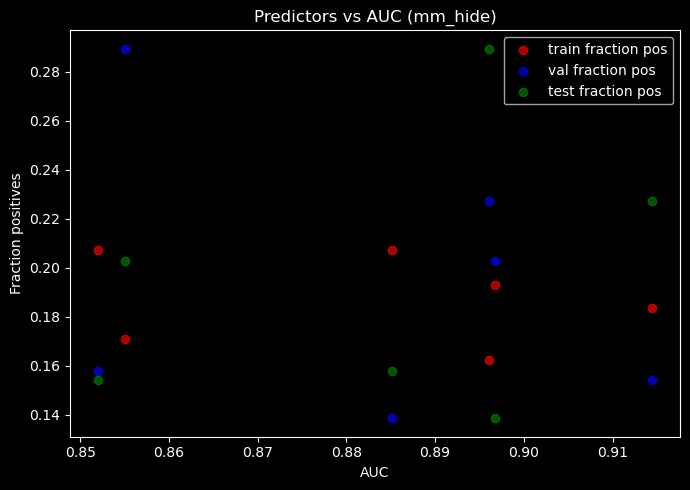

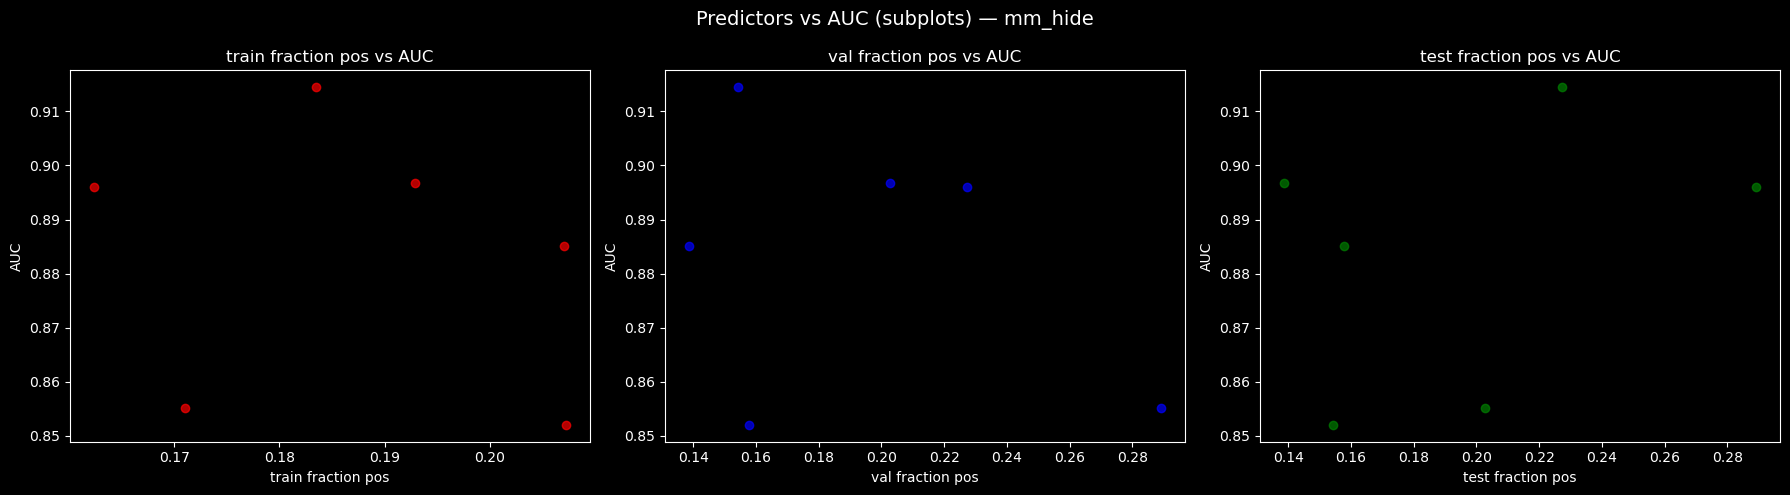

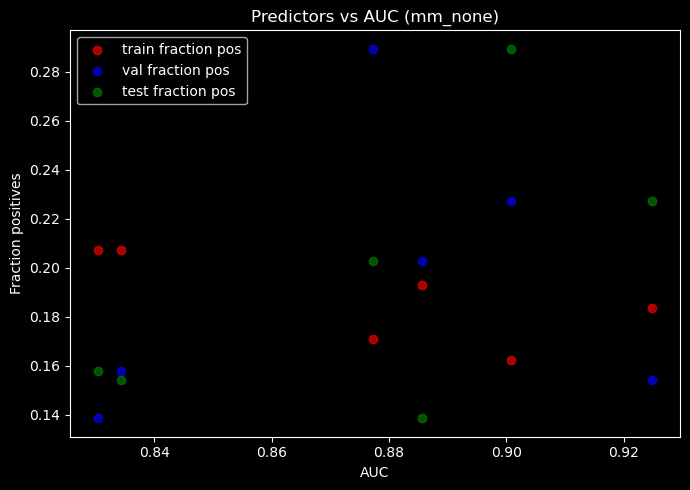

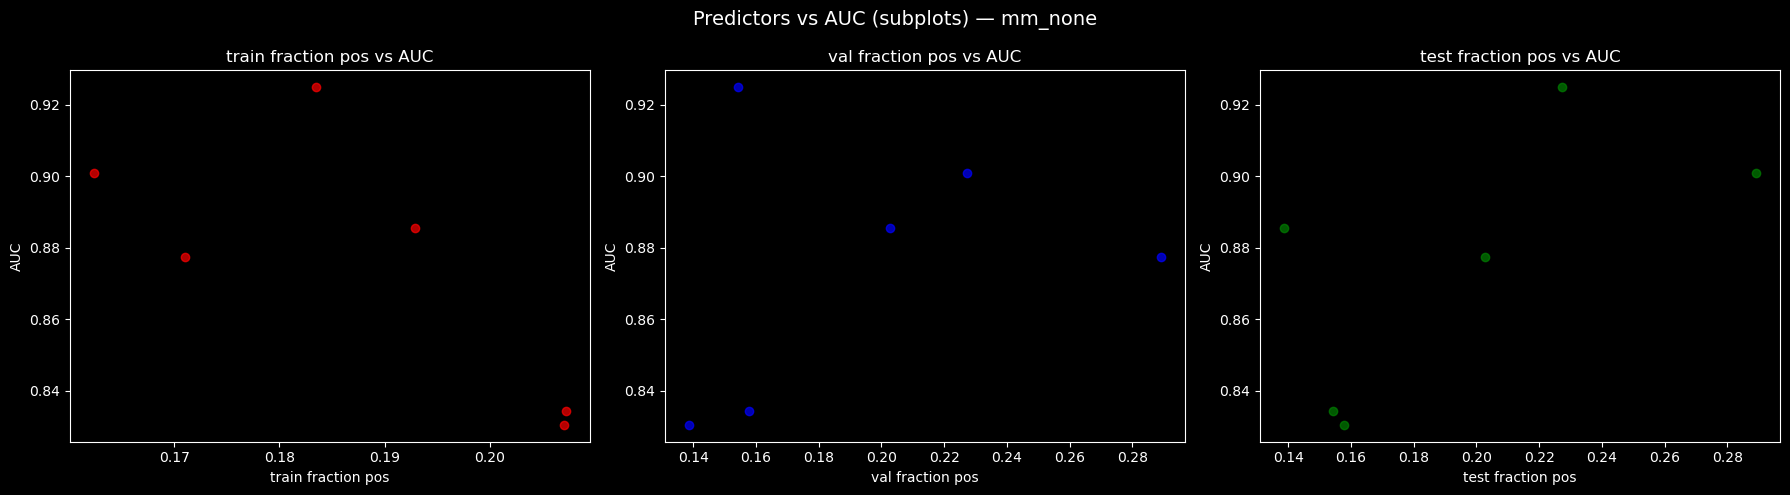

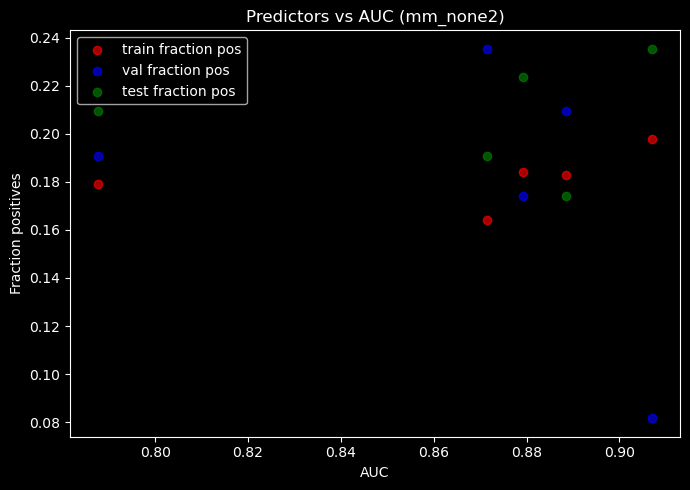

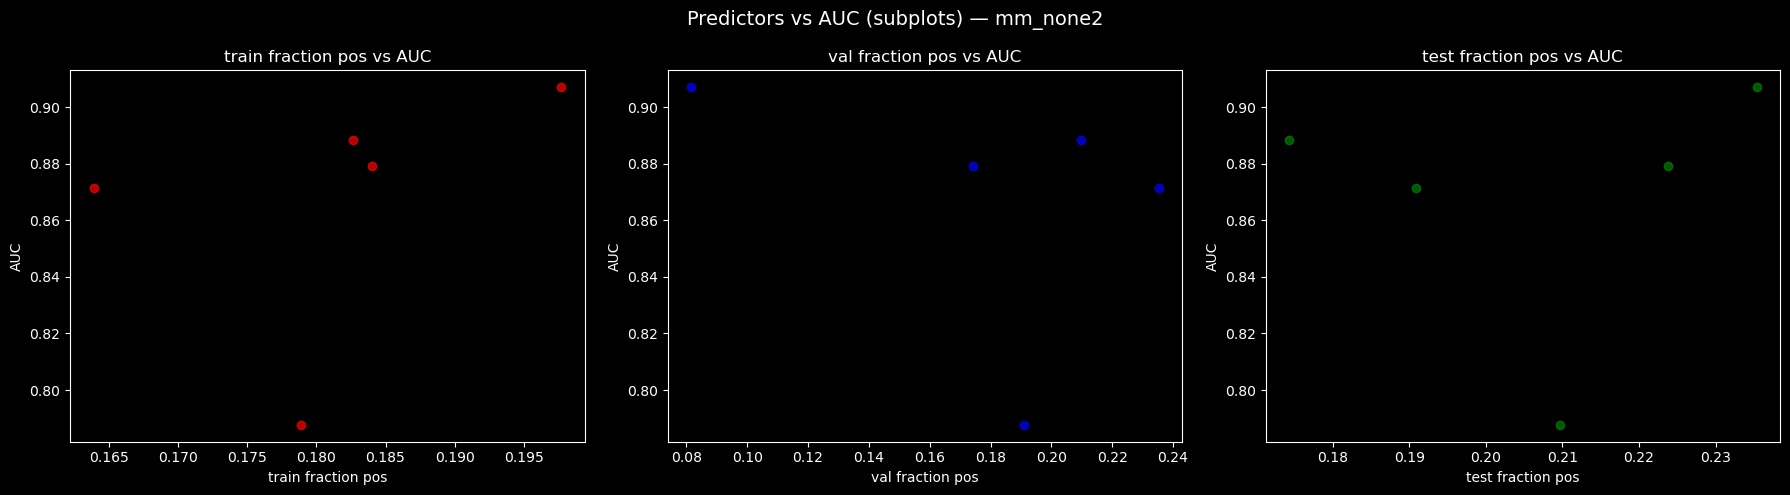

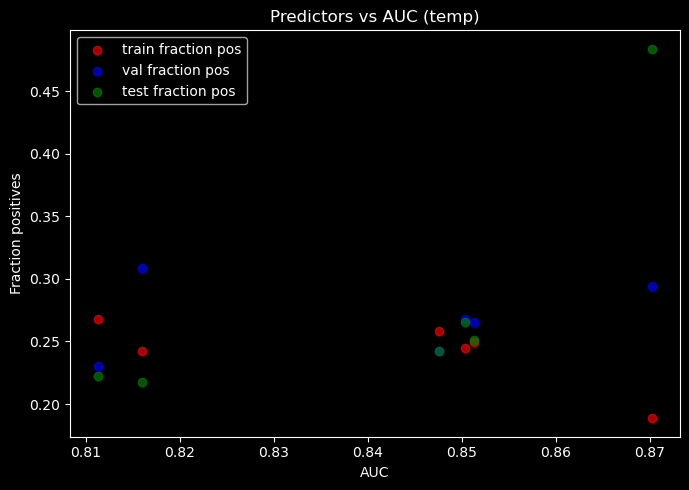

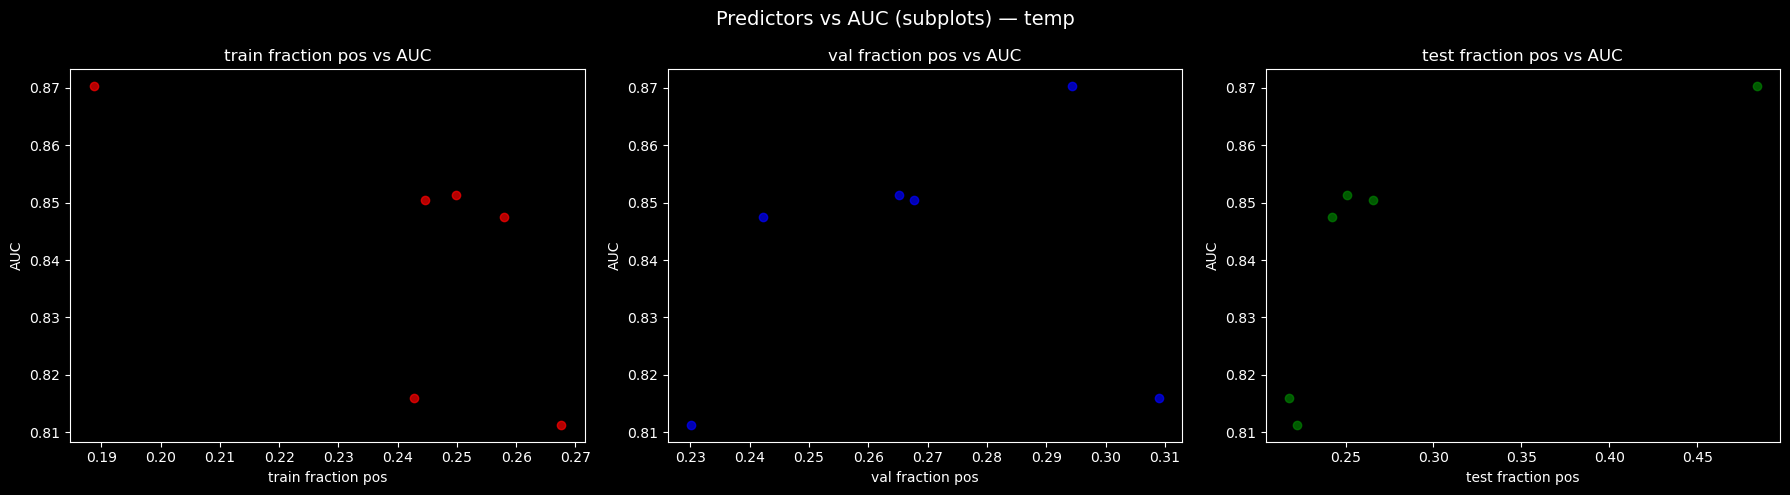

,p_intercept,p_train,p_val,p_test,beta_intercept,beta_train,beta_val,beta_test,se_intercept,se_train,se_val,se_test,t_intercept,t_train,t_val,t_test,df,n
exp,,,,,,,,,,,,,,,,,,
mm_hide,0.013022,0.034683,0.026057,0.059089,2.214232,-5.062812,-1.093876,-0.867238,0.255170,0.968244,0.180116,0.220715,8.677487,-5.228862,-6.073191,-3.929213,2,6
mm_none,0.034001,0.065953,0.082760,0.123227,2.611795,-6.937091,-1.136209,-1.102387,0.494297,1.875614,0.348907,0.427554,5.283858,-3.698571,-3.256478,-2.578356,2,6
mm_none2,0.630922,0.911374,0.747306,0.719459,1.578918,-1.223248,-1.028325,-1.483360,2.411280,8.730027,2.453186,3.145358,0.654805,-0.140120,-0.419179,-0.471603,1,5
temp,0.372037,0.423017,0.416515,0.444846,6.547807,-14.692884,-4.819604,-3.068118,5.738017,14.706912,4.743397,3.250390,1.141127,-0.999046,-1.016066,-0.943923,2,6


In [12]:
results = {}

for exp, gdf_exp in df.groupby("exp"):
    results[exp] = regression_for_experiment(exp, gdf_exp)

# Convert to a clean DataFrame
rows = []
for exp, res in results.items():
    if res is None:
        continue
    beta = res["beta"]
    se = res["se"]
    t = res["t"]
    p = res["p"]

    rows.append({
        "exp": exp,
        "p_intercept": p[0],
        "p_train": p[1],
        "p_val": p[2],
        "p_test": p[3],
        "beta_intercept": beta[0],
        "beta_train": beta[1],
        "beta_val": beta[2],
        "beta_test": beta[3],
        "se_intercept": se[0],
        "se_train": se[1],
        "se_val": se[2],
        "se_test": se[3],
        "t_intercept": t[0],
        "t_train": t[1],
        "t_val": t[2],
        "t_test": t[3],
        "df": res["df"],
        "n": res["n"],
    })

regression_summary = pd.DataFrame(rows).set_index("exp")
regression_summary


# Sort Model Results

## Get Model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
best_model_path = Path('../outputs4/o_mm_mask_norm/run3/best_model.pth')
model = DiagnosticModel(model_name = 'resnet50', include_weights = False, in_channels = 3)

checkpoint = torch.load(best_model_path, map_location=next(model.parameters()).device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
""

''

## Get Data

In [8]:
max_samples = None
data_dir = Path('/data/vision/polina/users/marcusbl/data')
dataset = DicomDataset(data_dir, max_samples = max_samples)
dataset.set_norm(norm_method = 'min-max', masked_norm = True, perc_norm = 0.02)

batch_size = 16
dataloader = DataLoader(dataset, shuffle = False, batch_size = batch_size)

Loading People Data:   0%|          | 0/30 [00:00<?, ?it/s]

Loading People Data: 100%|██████████| 30/30 [00:01<00:00, 24.08it/s]


##  Run the Model on Data (~2 min on cuda)

In [13]:
results = {
    "conf": [],
    "idx": [],
    "pred": [],
    "true": [],
} 

for idx, (data, labels) in enumerate(tqdm(dataloader)):
    data, labels = data.to(device), labels.to(device)
    outputs = model(data) # (B, 2)

    probs = torch.softmax(outputs, dim=1)               # (B, 2)
    _, preds = torch.max(outputs, dim=1)                # preds is (B)

    conf = probs[torch.arange(len(probs)), preds]       # confidence per sample = probability of prediciting that prediction

    results['conf'].extend(conf.tolist())
    results['idx'].extend([int(idx * batch_size + i) for i in range(len(labels))])
    results['pred'].extend(preds.tolist())
    results['true'].extend(labels.tolist())

results_df = pd.DataFrame(results)

100%|██████████| 458/458 [02:45<00:00,  2.77it/s]


## Display results by confidence 

In [14]:
incorrect_mask = results_df['pred'] != results_df['true']
incorrect_df = results_df[incorrect_mask]

In [15]:
def display_incorrect(incorrect_df: pd.DataFrame, dataset: DicomDataset, norm_params: None | dict = None, max_display: int=10, ):
    """
    Shows incorrect predictions with:
      - True label (top-left)
      - Predicted label (top-right)
      - Confidence (bottom-center)
    """
    incorrect_df = incorrect_df.sort_values(by='conf', ascending=False).reset_index(drop=True)
    
    # Fix Normalization to Whatever You Want
    if norm_params is not None:
        dataset.set_norm(norm_method = norm_params['norm_method'], 
                        masked_norm = norm_params['masked_norm'], 
                        perc_norm = norm_params['perc_norm'])

    # Set up Display
    num_display = min(len(incorrect_df), max_display)
    nrows = int(np.sqrt(num_display))
    ncols = int(num_display / nrows)

    # Taller figure: width fixed, height scales with number
    fig, axes = plt.subplots(
        nrows=nrows, 
        ncols=ncols, 
        figsize=(5 * nrows, 3 * ncols),
        squeeze=False
    )

    for i in range(nrows):
        for j in range(ncols):
            df_row_idx = i * nrows + j
            ax = axes[i, j]

            # Extract index and metadata
            df_row = incorrect_df.iloc[df_row_idx]
            display_idx = int(df_row['idx'])
            pred = df_row['pred']
            true = df_row['true']
            conf = df_row['conf']

            # Image extraction (assuming (img, label) format)
            img = dataset[display_idx][0][0]

            # Show image
            ax.imshow(img, cmap="gray")
            ax.axis("off")

            # Annotation text
            title = f"True: {true} | Pred: {pred} (Idx {display_idx})"
            if conf is not None:
                subtitle = f"Confidence: {conf:.3f}"
            else:
                subtitle = ""

            ax.set_title(title, fontsize=14, pad=10)
            ax.text(
                0.5, -0.12, subtitle,
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=12
            )

    plt.tight_layout()
    plt.show()


In [16]:
clean_norm_params = {
    'norm_method': None,
    'masked_norm': False,
    'perc_norm': 0
}

mm_norm_params = {
    'norm_method': 'min-max',
    'masked_norm': True,
    'perc_norm': 0,

}

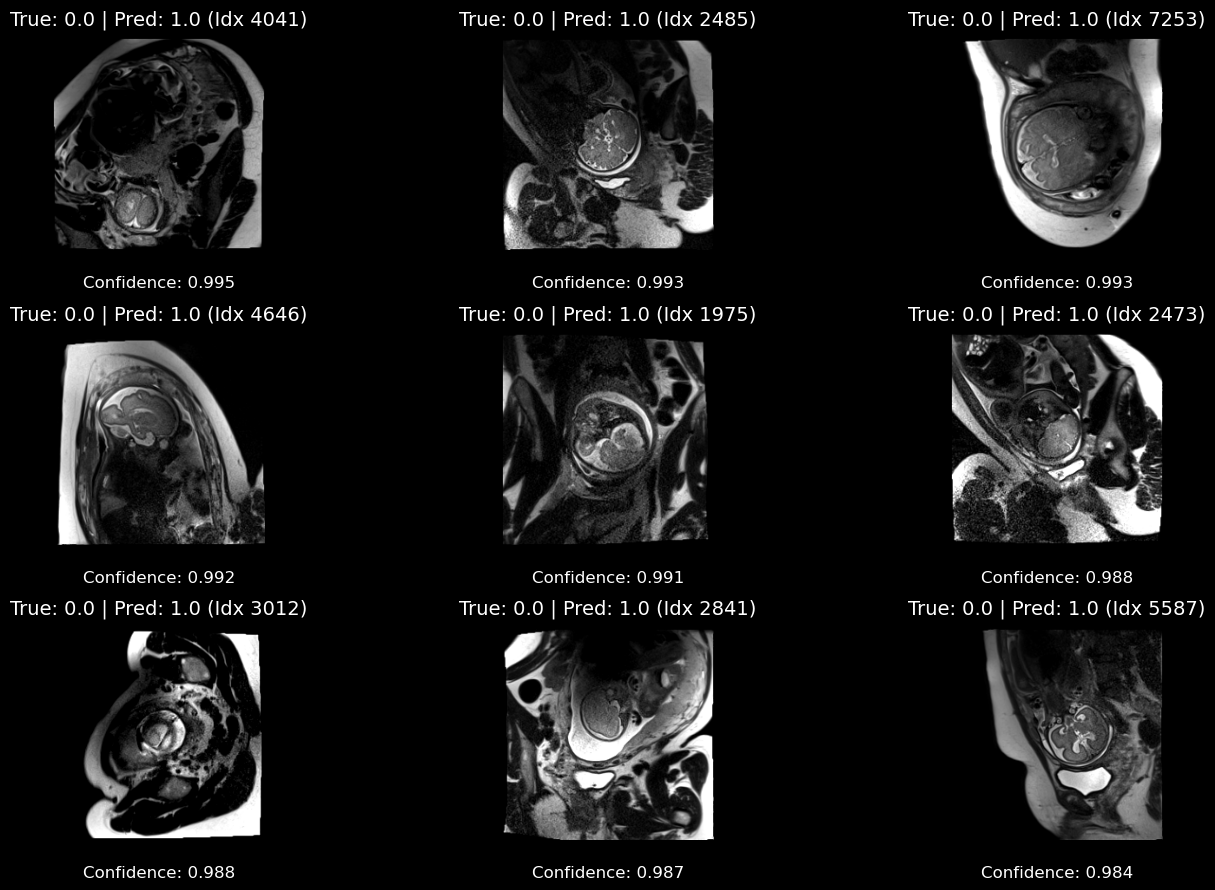

In [21]:
display_incorrect(incorrect_df[incorrect_df['pred'] == 1], dataset, mm_norm_params, max_display = 9)

<Axes: >

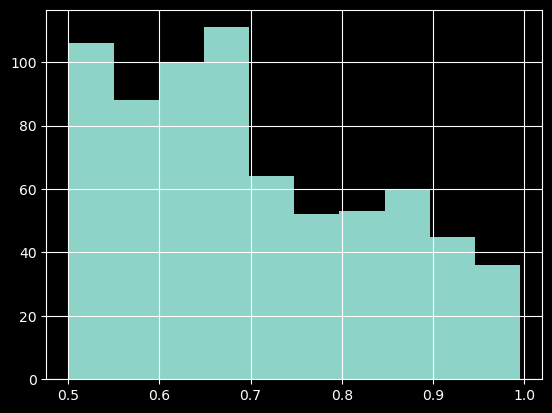

In [22]:
incorrect_df[incorrect_df['pred'] == 1]['conf'].hist()

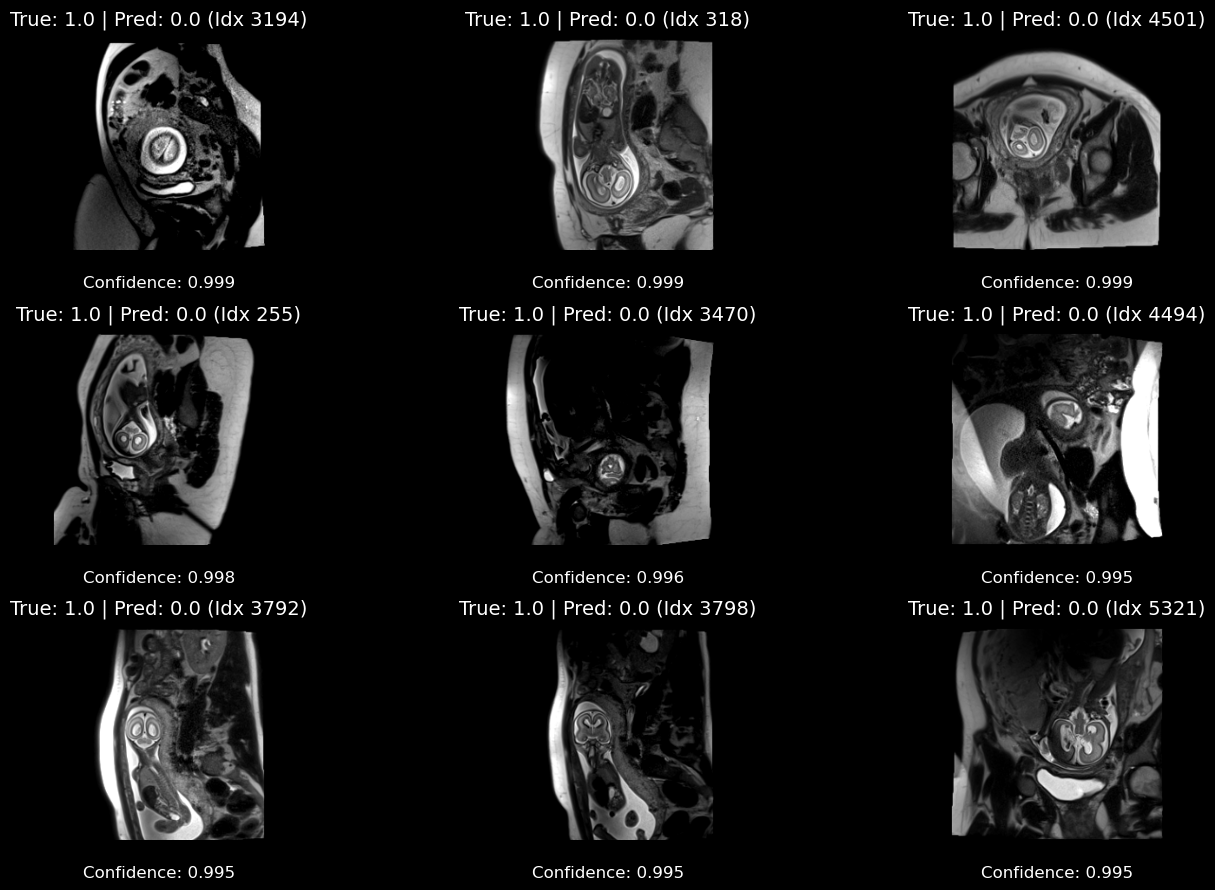

In [19]:
display_incorrect(incorrect_df[incorrect_df['pred'] == 0], dataset, mm_norm_params, max_display = 10)

<Axes: >

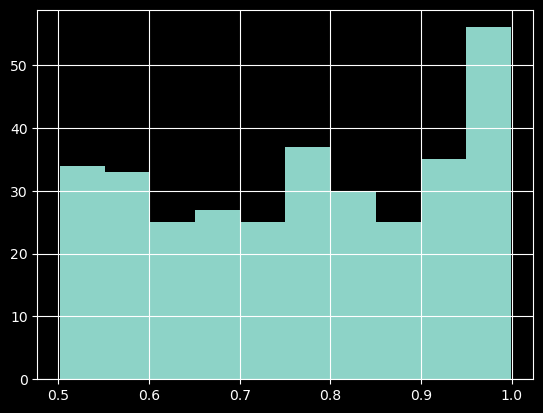

In [20]:
incorrect_df[incorrect_df['pred'] == 0]['conf'].hist()